In [1]:
import polars as pl
import matplotlib.pyplot as plt
import geopandas as gpd
import pyarrow.parquet as pq
import pandas as pd

# Paths

In [2]:
# tweets
tweets_tot = '../twitter_home_location_FR/tweets_geolocated_users_unified/cleaning_steps_files/tweets_geo_users_2014_2018_cleaned_lang_0.7_no_spammers.parquet'
tweets_ile_de_france = '../twitter_home_location_FR/tweets_geolocated_users_unified/cleaning_steps_files/tweets_geo_users_2014_2018_no_spammers_PARIS_LARGE_LARGE.parquet'

# users
users_ile_de_france = '../geo_ses_files/FR/user_geo_income_200m_threshold_0.7_PARIS_LARGE_LARGE.parquet'
#users_ile = '../geo_ses_files/FR/PARIS_LARGE_LARGE_users_200m_no_spammers.parquet'
users_ile_5_tweets = '../geo_ses_files/FR/PARIS_LARGE_LARGE_users_200m_at_leat_5_tweets_lang_FR_no_spammers.parquet'
users_ile_ses = '../geo_ses_files/FR/users_geo_income_200m_SES_USERS_PARIS_LARGE_LARGE.parquet'
users_tot_ses = '../geo_ses_files/FR/users_geo_income_200m_threshold_0.7_SES_USERS_NEW_no_spammers_2_classes.parquet'
#users_geo_income_200m_SES_USERS_PARIS_LARGE_LARGE.parquet

# Analysis of total data

### Users

#### Ile de France

In [3]:
# users no spammers
users_ile_df = pl.read_parquet(users_ile_de_france)
users_ile_df

user_id,num_tweets_per_user,tweets_ids,clean_text_light_list,idINSPIRE,ind_snv_mean,ind
str,u32,list[str],list[str],str,f64,f64
"""408631222""",128,"[""486136330762846209"", ""486137082214354944"", … ""989161054738505732""]","[""LISSFACTOR Lance le nouveau Luxter Men - Le premier soin lissant dédié aux Mâles!"", ""Coiffure de Paris-- Lancement du nouveau soin lissant pour les Hommes by"", … ""Gamme de Bonheur gains the volume of your hair 💪 @ Paris, France""]","""CRS3035RES200mN2891000E3757400""",42317.441651,266.5
"""155513807""",1121,"[""431444161095794688"", ""431746297822195712"", … ""1075708338145513472""]","[""Nouvel album d' en mai 2014! Toutes les infos et le trailer ici:"", ""Villagers présente son nouveau single produit par James Ford"", … ""Retrouvez la playlist DomiNoël sur 🎄❄️""]","""CRS3035RES200mN2892400E3760000""",34847.504088,1455.5
"""258765091""",619,"[""418912398138167296"", ""418912835822182400"", … ""1065263365017214976""]","[""Recevoir ce genre de nouvelles à 2h du matin. #Sad"", ""Y a vraiment des gens qui mériterait de crever. #Énervée #désabusée"", … ""Ah il est là. Il viendra pas dans le 93, donc bon.""]","""CRS3035RES200mN2892400E3768600""",17358.512256,1203.5
"""1056473701""",444,"[""480076227529957376"", ""480123774218829824"", … ""710189151728095232""]","[""Jamais je pourrais vivre en banlieue , laisser moi a Paris la j'y suis depuis ma naissance ça va aller !"", ""C'est long à expliquer et toi elle est passée ou t'as meuf ?"", … ""j'ai pas besoin de t'appeler""]","""CRS3035RES200mN2890600E3764400""",22868.032697,2908.5
"""1193084418""",72,"[""420972879329918976"", ""421010442656706560"", … ""758070623583305728""]","[""Merci beaucoup ... mais je ne suis pas encore très douée sur Twitter ... désolée! Au plaisir."", ""Quiche thon-potiron, recette Marmiton. Un vrai régal !!"", … ""Le bonheur de mes filles !!!! #bonheur #vacances #canaries #palmitospark @ Palmitos Park""]","""CRS3035RES200mN2882000E3770800""",34170.178543,247.0
…,…,…,…,…,…,…
"""550015838""",5,"[""686231437775880192"", ""687246408001433600"", … ""978230932506374144""]","[""Come back de la connasse !"", ""Vous êtes là à vouloir des meufs qui savent cuisiner mais toute votre vie vous êtes au grec et au kfc"", … ""Jordan il sert à quoi en fait ? Il est moche, lourd, pas drôle et il a le projet pro le plus éclaté de toute l’histoire de la tv réalité flemme 😪 #LesAnges10""]","""CRS3035RES200mN2886200E3762000""",27814.765865,1787.0
"""908285966""",347,"[""480074556460507138"", ""480646414348070912"", … ""1050136043159207937""]","[""Et 1 et 2 et 3 - 0 #FRASUI 🇫🇷"", ""avec david qui flippe de la pluie 😂😂😂"", … ""Mais loi je veux une histoire d’amiur""]","""CRS3035RES200mN2891600E3762400""",25280.87424,1892.5
"""928534590""",132,"[""479744282610642944"", ""480675474411372544"", … ""828402470091161600""]","[""Les mecs qui font les mecs stricte autoritaire tu fais s'que j'te dis et tu ftg mais eux s'permettent tout et n'importe quoi on en parle?"", ""C'est chaud de pas avoir Bein"", … ""Ca va me manqué c'était mon confident 😂""]","""CRS3035RES200mN2899600E3753000""",19004.982985,335.0


In [4]:
# users with ses ile de france -> removed users with not valid cells info (income)
users_ile_ses_df = pl.read_parquet(users_ile_ses)
users_ile_ses_df

user_id,num_users,SES_users,num_tweets_per_user,idINSPIRE,ind_snv_mean,ind
str,u32,str,u32,str,f64,f64
"""44854323""",1,"""high""",13,"""CRS3035RES200mN2878000E3772200""",34944.953719,121.0
"""825270648""",11,"""lower""",729,"""CRS3035RES200mN2890000E3763400""",21805.193309,2511.0
"""1107051546""",1,"""lower""",1160,"""CRS3035RES200mN2871200E3744800""",16667.701367,548.5
"""1160582209""",3,"""medium""",537,"""CRS3035RES200mN2898000E3799400""",26670.735849,185.5
"""944400103""",1,"""medium""",881,"""CRS3035RES200mN2889600E3777200""",32261.586761,211.5
…,…,…,…,…,…,…
"""2291361747""",1,"""high""",993,"""CRS3035RES200mN2871400E3768000""",34063.587662,154.0
"""870388616""",1,"""high""",1212,"""CRS3035RES200mN2904600E3749200""",34002.714159,113.0
"""1114889935""",8,"""high""",812,"""CRS3035RES200mN2891000E3756200""",51080.326393,816.5


In [5]:
# users no spammers at least 5 tweets
users_ile_5_tweets_df = pl.read_parquet('../geo_ses_files/FR/PARIS_LARGE_LARGE_users_200m_at_leat_5_tweets_lang_FR_no_spammers.parquet')
users_ile_5_tweets_df

user_id,idINSPIRE,SES_users,__index_level_0__,num_tweets
str,str,str,i64,u32
"""766675172""","""CRS3035RES200mN2848200E3756400""","""lower""",73622,673
"""526921799""","""CRS3035RES200mN2894800E3754400""","""high""",60622,282
"""94396209""","""CRS3035RES200mN2885000E3756200""","""medium""",82129,40
"""719822231""","""CRS3035RES200mN2858800E3766200""","""medium""",71714,336
"""1148980268""","""CRS3035RES200mN2902200E3759800""","""high""",6701,541
…,…,…,…,…
"""1225932566""","""CRS3035RES200mN2881000E3761800""","""lower""",9484,191
"""1120057554""","""CRS3035RES200mN2897400E3768400""","""lower""",5426,48
"""568333623""","""CRS3035RES200mN2875800E3763400""","""lower""",64059,945


In [6]:
# merge users df with num of tweets per user and SES to see how many per class we lose bu cutting
users_ile_merged_df = users_ile_df.join(users_ile_ses_df, on='user_id')
users_ile_merged_df

user_id,num_tweets_per_user,tweets_ids,clean_text_light_list,idINSPIRE,ind_snv_mean,ind,num_users,SES_users,num_tweets_per_user_right,idINSPIRE_right,ind_snv_mean_right,ind_right
str,u32,list[str],list[str],str,f64,f64,u32,str,u32,str,f64,f64
"""44854323""",11,"[""575239572897951744"", ""575239995599933440"", … ""701143029671972867""]","[""Quand tu commences à insulter ton code, tu n'as qu'une seule alternative : effacer la fonction et…"", ""Quand tu commences à insulter ton code, tu n'as qu'une seule alternative : effacer la fonction et…"", … ""Combien de temps pour avoir votre gaufre ? #DisneylandParis #cestlong #javaisfaim""]","""CRS3035RES200mN2878000E3772200""",34944.953719,121.0,1,"""high""",13,"""CRS3035RES200mN2878000E3772200""",34944.953719,121.0
"""825270648""",677,"[""437869225424998400"", ""439533776293867520"", … ""1065945891272577024""]","[""Vient de publier une photo @ Mère Lachaise (La)"", ""#César2014 #GuillaumeEtLesGarçonsATable avec ton César du meilleur film (et les autres!) yeeesssss!!!"", … ""“Debout les femmes”: Brigitte et 37 autres musiciennes reprennent l'hymne du MLF via""]","""CRS3035RES200mN2890000E3763400""",21805.193309,2511.0,11,"""lower""",729,"""CRS3035RES200mN2890000E3763400""",21805.193309,2511.0
"""1107051546""",747,"[""480067388449505281"", ""482041682788376576"", … ""1064466175319527425""]","[""J'ai tellement sauté , j'ai fais tombé mon Sprite"", ""J'ai appris mais dans l'brevet des fois ya grv des truc qu'on a pas appris"", … ""We c tout mtn compare à ce que nous ont a Ahahahah""]","""CRS3035RES200mN2871200E3744800""",16667.701367,548.5,1,"""lower""",1160,"""CRS3035RES200mN2871200E3744800""",16667.701367,548.5
"""1160582209""",412,"[""480458257279246336"", ""480655919047786496"", … ""1077529046710448128""]","[""Stiles il couche avec tt le monde --"" Malia et après Lydia ..."", ""On est dimanche donc ma mère fait péter le zouk et le compas dans la maison et ce midi on mange riz et haricots rouges !!! #JvaisBienBouffer"", … ""Mais c’est le meilleur jus au monde 😩😩😩😩😩""]","""CRS3035RES200mN2898000E3799400""",26670.735849,185.5,3,"""medium""",537,"""CRS3035RES200mN2898000E3799400""",26670.735849,185.5
"""944400103""",702,"[""480860530731925505"", ""482444386010423297"", … ""980049924946649088""]","[""Il ma dit, je cite ""oh je crois que le Portugal n'aime rien gagner 😉"". Mon prof d'espagnol."", """"tu va gouter a ma vengeance et tu verra que mon sourit voudra tout dire."""", … ""Pk y a des gens ils ont pas d personnalité et ils te copient genre ? La vie vous soulez frère trouvez vous VOS PROPRES BY""]","""CRS3035RES200mN2889600E3777200""",32261.586761,211.5,1,"""medium""",881,"""CRS3035RES200mN2889600E3777200""",32261.586761,211.5
…,…,…,…,…,…,…,…,…,…,…,…,…
"""2291361747""",794,"[""491704047301558273"", ""491839532334346241"", … ""597436943387983872""]","[""Snap je m'en fou de ma tête c'est le but de Snap et il y a des gens qui screen je comprend pas votre but."", ""Je la fav mais elle viens pas parler :/"", … ""Je vais désactivé ce compte. Bye 😉😉😉""]","""CRS3035RES200mN2871400E3768000""",34063.587662,154.0,1,"""high""",993,"""CRS3035RES200mN2871400E3768000""",34063.587662,154.0
"""870388616""",1070,"[""479904574292361216"", ""480672881026670595"", … ""1022168887318786048""]","[""la petite soirée improvisée d'hier était plutot sympathique"", ""jeudi je passe à 8h à l'oral, je dois etre a Pontoise vers 7h45, ma vie est archi nulle."", … ""Donc là je viens de voir un petit de même pas 13 ans sur un vélo faire Uber Eats c n’importe quoi !""]","""CRS3035RES200mN2904600E3749200""",34002.714159,113.0,1,"""high""",1212,"""CRS3035RES200mN2904600E3749200""",34002.714159,113.0
"""1114889935""",749,"[""418680577940652032"", ""418681103600189440"", … ""773524300469067780""]","[""Bonne année à tous, venez fêter ça avec nous par ici : !"", ""Bonne année de la part de , un de nos rédacteurs COOOL !"", … ""New concept Hippo, l'équipe y était (la fille au tattoo c'est nous ! ) #daddycoool #hippopotamus #newc

Users with less than 5 tweets: 540
Num users in lower class: 134
Num users in middle class: 159
Num users in high class: 247
Users with at least 5 tweets: 30595
Num users in lower class: 10252
Num users in middle class: 10226
Num users in high class: 10117


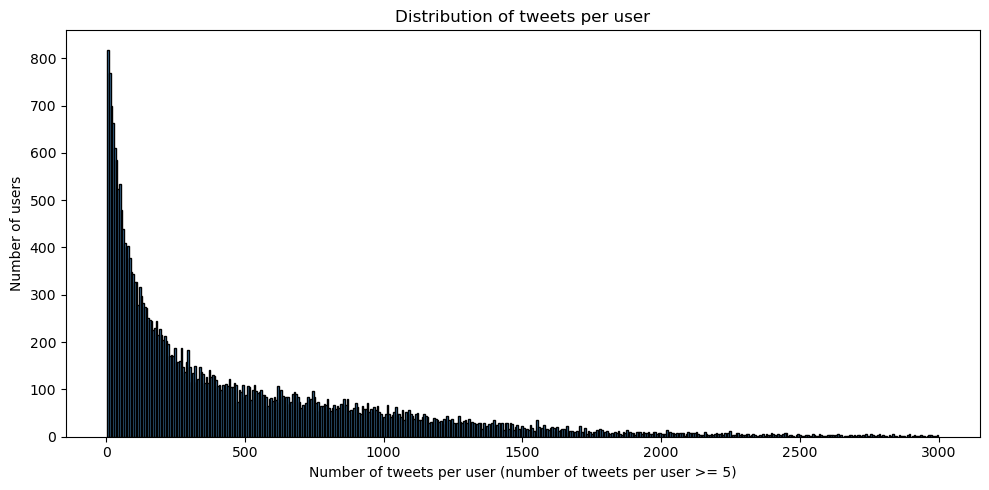



Users with less than 15 tweets: 1849
Num users in lower class: 541
Num users in middle class: 552
Num users in high class: 756
Users with at least 15 tweets: 29286
Num users in lower class: 9845
Num users in middle class: 9833
Num users in high class: 9608


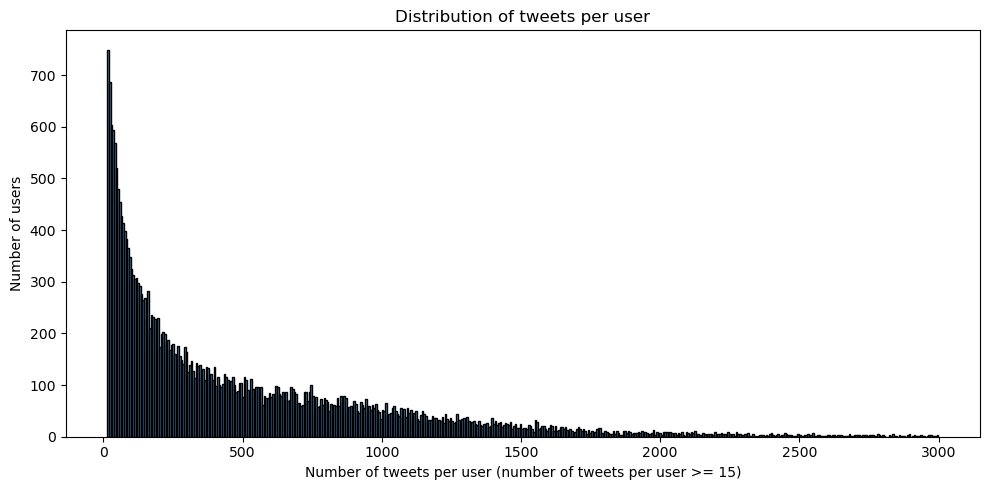



Users with less than 30 tweets: 3584
Num users in lower class: 1110
Num users in middle class: 1104
Num users in high class: 1370
Users with at least 30 tweets: 27551
Num users in lower class: 9276
Num users in middle class: 9281
Num users in high class: 8994


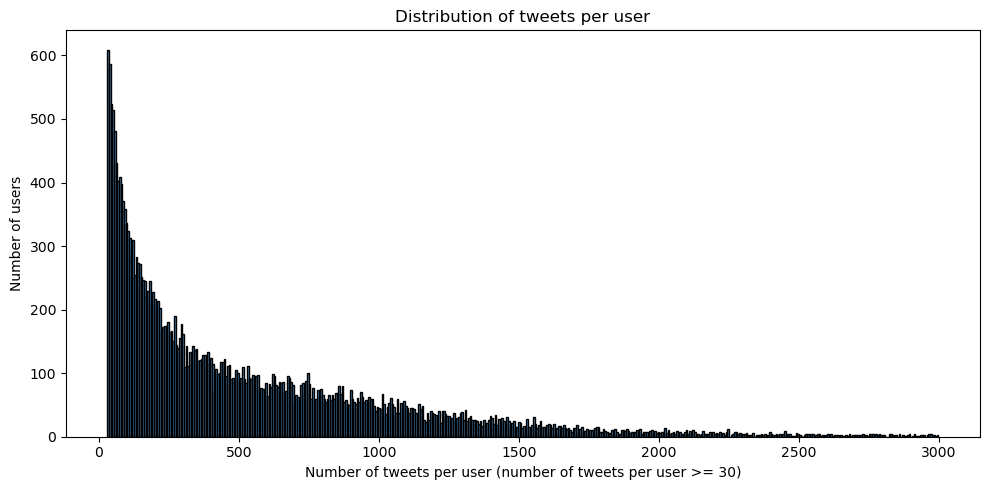



Users with less than 50 tweets: 5488
Num users in lower class: 1713
Num users in middle class: 1702
Num users in high class: 2073
Users with at least 50 tweets: 25647
Num users in lower class: 8673
Num users in middle class: 8683
Num users in high class: 8291


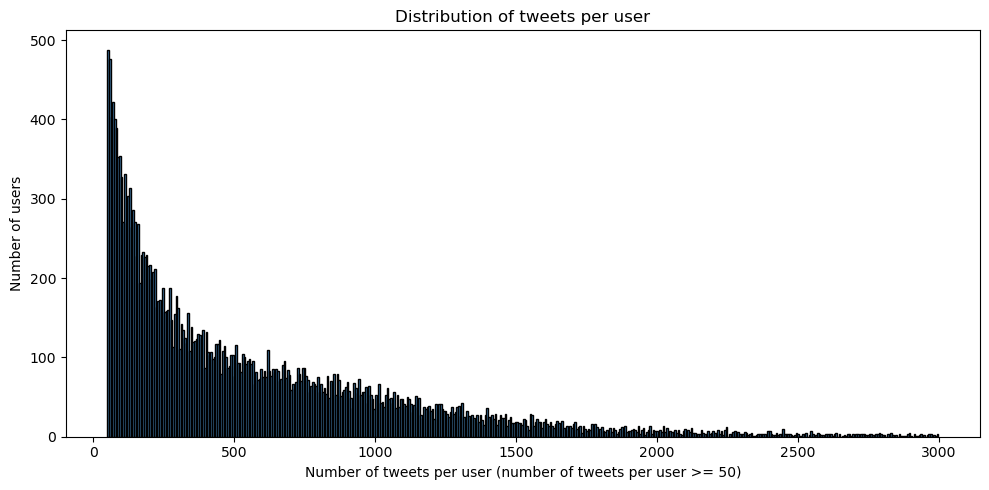



Users with less than 100 tweets: 8900
Num users in lower class: 2810
Num users in middle class: 2761
Num users in high class: 3329
Users with at least 100 tweets: 22235
Num users in lower class: 7576
Num users in middle class: 7624
Num users in high class: 7035


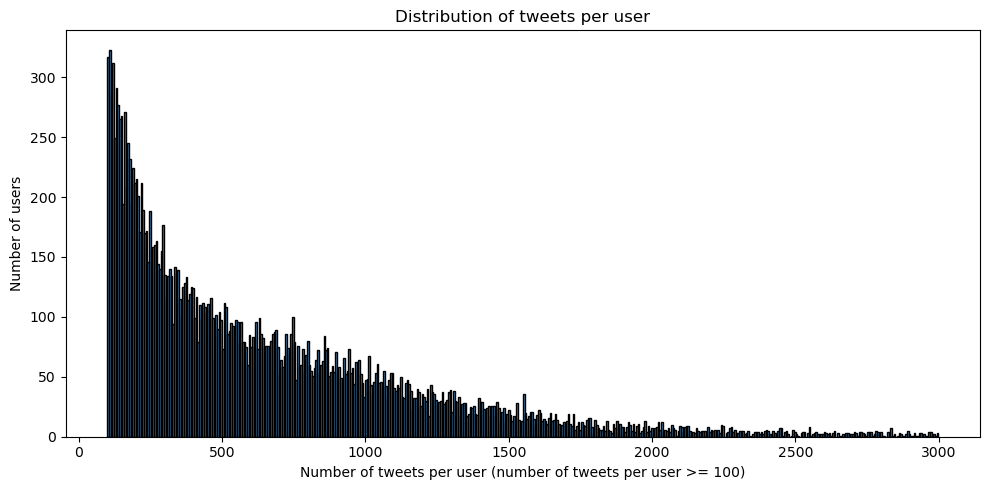



Users with less than 500 tweets: 20146
Num users in lower class: 6532
Num users in middle class: 6539
Num users in high class: 7075
Users with at least 500 tweets: 10989
Num users in lower class: 3854
Num users in middle class: 3846
Num users in high class: 3289


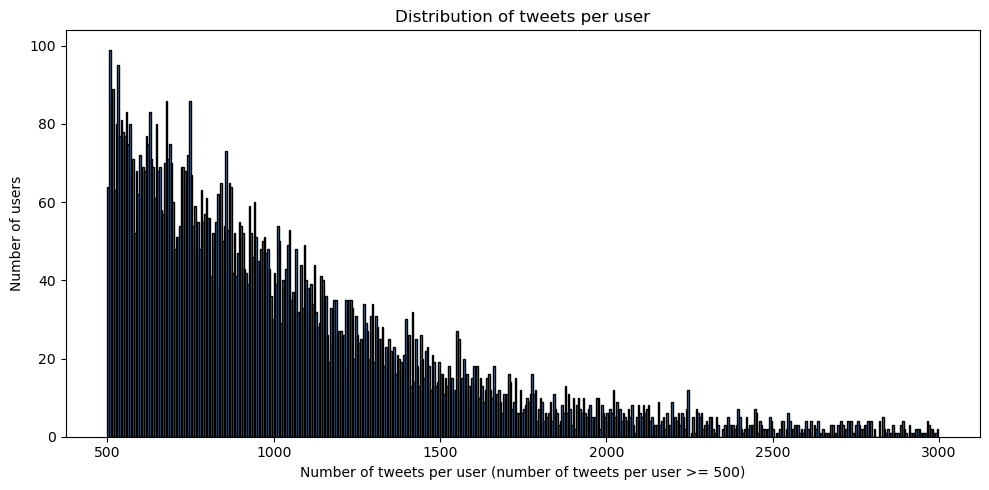



Users with less than 1000 tweets: 26270
Num users in lower class: 8760
Num users in middle class: 8660
Num users in high class: 8850
Users with at least 1000 tweets: 4865
Num users in lower class: 1626
Num users in middle class: 1725
Num users in high class: 1514


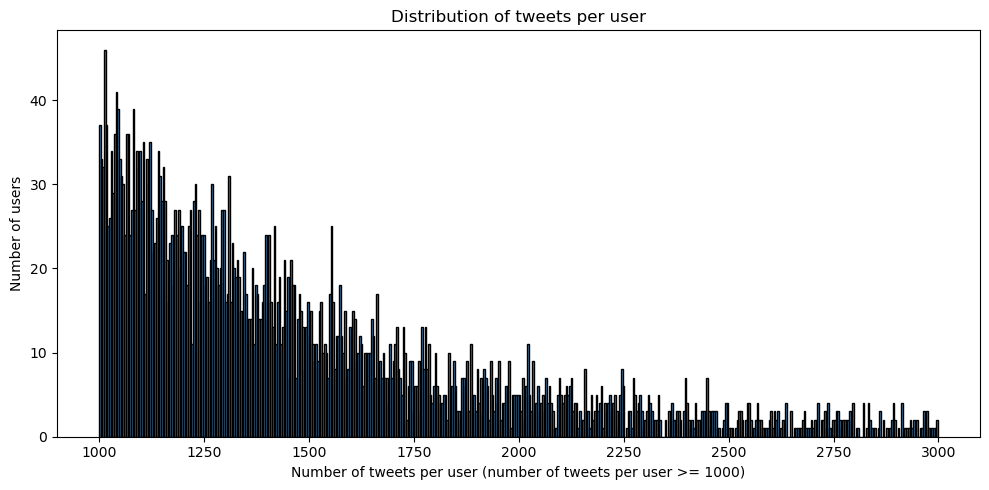

In [ ]:
# print number of users with at least n tweets
n_list = [5, 15, 30, 50, 100, 500, 1000]

df_lower_tot = pd.DataFrame()
df_major_tot = pd.DataFrame()

for n in n_list:

    filtered_df = users_ile_merged_df.filter(pl.col('num_tweets_per_user') < n)
    num_users = len(filtered_df)
    #num_users_small = users_ile_merged_df.filter(pl.col('num_tweets_per_user') < n)
    print(f'Users with less than {n} tweets: {num_users}')
    print('Num users in lower class:', len(filtered_df.filter(pl.col('SES_users') == 'lower')))
    print('Num users in middle class:', len(filtered_df.filter(pl.col('SES_users') == 'medium')))
    print('Num users in high class:', len(filtered_df.filter(pl.col('SES_users') == 'high')))
    df_lower = pd.DataFrame({'Less than N tweets -> N': [n], 
                       'lower class': [len(filtered_df.filter(pl.col('SES_users') == 'lower'))], 
                       'medium class': [len(filtered_df.filter(pl.col('SES_users') == 'medium'))],
                       'high class': [len(filtered_df.filter(pl.col('SES_users') == 'high'))]
                       })
    df_lower_tot = pd.concat([df_lower_tot, df_lower])
    
    filtered_major_df = users_ile_merged_df.filter(pl.col('num_tweets_per_user') >= n)
    num_users = len(filtered_major_df)
    #num_users_small = users_ile_merged_df.filter(pl.col('num_tweets_per_user') < n)
    print(f'Users with at least {n} tweets: {num_users}')
    print('Num users in lower class:', len(filtered_major_df.filter(pl.col('SES_users') == 'lower')))
    print('Num users in middle class:', len(filtered_major_df.filter(pl.col('SES_users') == 'medium')))
    print('Num users in high class:', len(filtered_major_df.filter(pl.col('SES_users') == 'high')))
    df_major = pd.DataFrame({'Less than N tweets -> N': [n], 
                           'lower class': [len(filtered_major_df.filter(pl.col('SES_users') == 'lower'))], 
                           'medium class': [len(filtered_major_df.filter(pl.col('SES_users') == 'medium'))],
                           'high class': [len(filtered_major_df.filter(pl.col('SES_users') == 'high'))]
                           })
    df_major_tot = pd.concat([df_major_tot, df_major])
    
    filtered_plot = filtered_major_df.filter(pl.col('num_tweets_per_user') < 3000)
    tweet_counts = filtered_plot["num_tweets_per_user"].to_numpy()

    plt.figure(figsize=(10, 5))
    plt.hist(tweet_counts, bins=500, edgecolor='black', color='steelblue')
    plt.xlabel(f"Number of tweets per user (number of tweets per user >= {n})")
    plt.ylabel("Number of users")
    plt.title("Distribution of tweets per user")
    plt.tight_layout()
    plt.savefig(f"tweets_thresholds/tweet_distribution > {n} tweets.png", dpi=150)
    plt.show()

    print('\n')

df_lower_tot.to_csv('tweets_thresholds/tweets < n.csv', index=False)
df_major_tot.to_csv('tweets_thresholds/tweets > n.csv', index=False)

### Total

In [32]:
users_tot_ses_df = pl.read_parquet(users_tot_ses)
users_tot_ses_df

user_id,num_users,SES_users,num_tweets_per_user,idINSPIRE,ind_snv_mean,ind
str,u32,str,u32,str,f64,f64
"""410719653""",3,"""high""",724,"""CRS3035RES200mN2746200E3449400""",27372.121419,380.5
"""41091972""",1,"""high""",391,"""CRS3035RES200mN2291600E3957400""",33493.180556,36.0
"""412285533""",1,"""high""",12,"""CRS3035RES200mN2318600E3863000""",31062.55625,80.0
"""412408200""",1,"""lower""",520,"""CRS3035RES200mN2596800E3694000""",14094.816061,261.5
"""412497918""",8,"""lower""",421,"""CRS3035RES200mN2895600E3758000""",20633.9862,1942.0
…,…,…,…,…,…,…
"""1035696786""",9,"""medium""",14,"""CRS3035RES200mN2891200E3764600""",23169.295756,2438.5
"""1037003137""",3,"""lower""",28,"""CRS3035RES200mN2878800E3769200""",17892.928889,225.0
"""1040115841""",3,"""lower""",349,"""CRS3035RES200mN2879600E3768000""",18172.259428,856.5


### Tweets

#### Total tweets cleaned

In [ ]:
# tweets tot after cleaning
tweets_tot_df = pl.read_parquet(tweets_tot)
tweets_tot_df

id,user_id,created_at,lang,clean_light,clean_full,num_words_full,final_lang
str,str,datetime[μs],str,str,str,u32,str
"""480061153713086464""","""1000010779""",2014-06-20 18:54:32,"""fr""","""Jv regarder lmatch au grec ave…","""Jv regarder lmatch au grec ave…",8,"""fr"""
"""506030589418688512""","""1000010779""",2014-08-31 10:47:48,"""fr""","""Jv voir le match de mon équipe""","""Jv voir le match de mon équipe""",7,"""fr"""
"""506031611423752192""","""1000010779""",2014-08-31 10:51:52,"""fr""","""Jsuis blessé vite fait j'ai fa…","""Jsuis blessé vite fait j'ai fa…",9,"""fr"""
"""506178319550017536""","""1000010779""",2014-08-31 20:34:50,"""fr""","""Waa j'suis mort de rire ce mec…","""Waa j'suis mort de rire ce mec…",23,"""fr"""
"""506504850365243393""","""1000010779""",2014-09-01 18:12:21,"""fr""","""Fini les 3h du mat...""","""Fini les 3h du mat""",5,null
…,…,…,…,…,…,…,…
"""742854054473261056""","""999992646""",2016-06-14 22:59:42,"""fr""","""Ils chantent super bien les pe…","""Ils chantent super bien les pe…",8,"""fr"""
"""744527517604798465""","""999992646""",2016-06-19 13:49:27,"""fr""","""Ya certaines personnes vaut mi…","""Ya certaines personnes vaut mi…",26,"""fr"""
"""748214304114118656""","""999992646""",2016-06-29 17:59:25,"""fr""","""Bon mon dossier pas au point p…","""Bon mon dossier pas au point p…",8,"""fr"""


#### Tweets ile de france cleaned

In [15]:
# tweets ile de france after cleaning (no threshold on number of tweets)
df = pd.read_parquet(tweets_ile_de_france)
'''table = pq.read_table(tweets_ile_de_france)
df = pl.from_arrow(
    table.drop(["geometry"])   # replace "geometry" with actual column name
)'''

'''gdf = gpd.read_file(tweets_ile_de_france)   # or .gpkg, .shp, etc.
tweets_ile_df = pl.from_pandas(gpd.drop(columns=["geometry"]))
#tweets_tot_df.join(users_ile_df, on='user_id')
tweets_ile_df'''
df

,user_id,x_home_left,y_home_left,home_tweet_count_left,home_geometry_left,idINSPIRE_x,id_carr_1km,idcar_nat,i_est_200,i_est_1km,...,text,created_at,source,lang,lang_user,reply_to_tweet_id,reply_to_user_id,home_tweet_count,idINSPIRE_y,ind_snv_mean_y
0,1000010779,3771800.0,2894000.0,10,b'\x01\x01\x00\x00\x00\x00\x00\x00\x00\xcc\xc6...,CRS3035RES200mN2894000E3771800,CRS3035RES1000mN2894000E3771000,CRS3035RES1000mN2894000E3771000,0.0,0.0,...,Bande de plouuuk,2014-06-19 22:11:17,Twitter for Android,fr,fr,None,None,10,CRS3035RES200mN2894000E3771800,19480.740266
1,1000010779,3771800.0,2894000.0,10,b'\x01\x01\x00\x00\x00\x00\x00\x00\x00\xcc\xc6...,CRS3035RES200mN2894000E3771800,CRS3035RES1000mN2894000E3771000,CRS3035RES1000mN2894000E3771000,0.0,0.0,...,Jv regarder lmatch au grec avec mes potes,2014-06-20 18:54:32,Twitter for Android,fr,fr,None,None,10,CRS3035RES200mN2894000E3771800,19480.740266
2,1000010779,3771800.0,2894000.0,10,b'\x01\x01\x00\x00\x00\x00\x00\x00\x00\xcc\xc6...,CRS3035RES200mN2894000E3771800,CRS3035RES1000mN2894000E3771000,CRS3035RES1000mN2894000E3771000,0.0,0.0,...,Il est mordu Suarez,2014-06-24 19:22:38,Twitter for Android,fr,fr,None,None,10,CRS3035RES200mN2894000E3771800,19480.740266
3,1000010779,3771800.0,2894000.0,10,b'\x01\x01\x00\x00\x00\x00\x00\x00\x00\xcc\xc6...,CRS3035RES200mN2894000E3771800,CRS3035RES1000mN2894000E3771000,CRS3035RES1000mN2894000E3771000,0.0,0.0,...,Comme si j'allai céper,2014-06-27 21:06:30,Twitter for Android,fr,fr,None,None,10,CRS3035RES200mN2894000E3771800,19480.740266
4,1000010779,3771800.0,2894000.0,10,b'\x01\x01\x00\x00\x00\x00\x00\x00\x00\xcc\xc6...,CRS3035RES200mN2894000E3771800,CRS3035RES1000mN2894000E3771000,CRS3035RES1000mN2894000E3771000,0.0,0.0,...,Musique,2014-07-20 11:23:01,Twitter for Android,fr,fr,None,None,10,CRS3035RES200mN2894000E3771800,19480.740266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26916609,999984866,3771000.0,2886800.0,208,b'\x01\x01\x00\x00\x00\x00\x00\x00\x00<\xc5LA\...,CRS3035RES200mN2886800E3771000,CRS3035RES1000mN2886000E3771000,CRS3035RES200mN2886800E3771000,0.0,0.0,...,Mbappé encore,2017-05-09 20:12:01,Twitter for iPhone,fr,fr,None,None,208,CRS3035RES200mN2886800E3771000,31714.782322
26916610,999984866,3771000.0,2886800.0,208,b'\x01\x01\x00\x00\x00\x00\x00\x00\x00<\xc5LA\...,CRS3035RES200mN2886800E3771000,CRS3035RES1000mN2886000E3771000,CRS3035RES200mN2886800E3771000,0.0,0.0,...,Sans APB j'ai déjà deux écoles,2017-05-18 08:46:53,Twitter for iPhone,fr,fr,None,None,208,CRS3035RES200mN2886800E3771000,31714.782322
26916611,999984866,3771000.0,2886800.0,208,b'\x01\x01\x00\x00\x00\x00\x00\x00\x00<\xc5LA\...,CRS3035RES200mN2886800E3771000,CRS3035RES1000mN2886000E3771000,CRS3035RES200mN2886800E3771000,0.0,0.0,...,@seksako Jai 4 école je t'en bibi une stuve,2017-06-08 13:34:54,Twitter for iPhone,fr,fr,None,None,208,CRS3035RES200mN2886800E3771000,31714.782322
26916612,999984866,3771000.0,2886800.0,208,b'\x01\x01\x00\x00\x00\x00\x00\x00\x00<\xc5LA\...,CRS3035RES200mN2886800E3771000,CRS3035RES1000mN2886000E3771000,CRS3035RES200mN2886800E3771000,0.0,0.0,...,@seksako Bts logistique à Tremblay Paris et j'...,2017-06-08 13:37:43,Twitter for iPhone,fr,fr,None,None,208,CRS3035RES200mN2886800E3771000,31714.782322


# Analysis of our Train/test sets

# Statistics

## Tweets per user

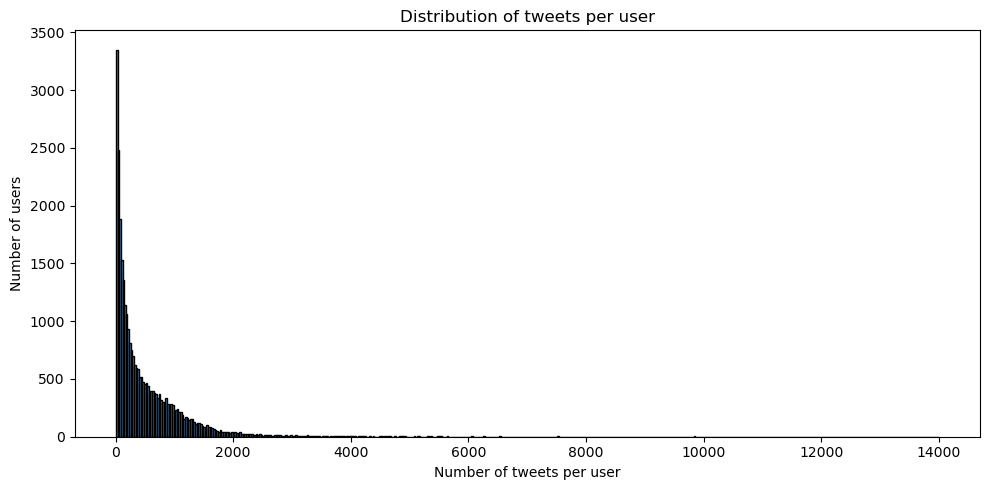

In [ ]:
# assuming your df has columns: user_id, n_tweets
tweet_counts = users_ile_5_tweets["num_tweets"].to_numpy()

plt.figure(figsize=(10, 5))
plt.hist(tweet_counts, bins=500, edgecolor='black', color='steelblue')
plt.xlabel("Number of tweets per user")
plt.ylabel("Number of users")
plt.title("Distribution of tweets per user")
plt.tight_layout()
plt.savefig("tweet_distribution.png", dpi=150)
plt.show()